In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip '/content/drive/MyDrive/UECFood100.zip' -d ./UECFOOD100

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: ./UECFOOD100/UECFOOD100/65/9192.jpg  
  inflating: ./UECFOOD100/UECFOOD100/65/9228.jpg  
  inflating: ./UECFOOD100/UECFOOD100/65/9235.jpg  
  inflating: ./UECFOOD100/UECFOOD100/65/bb_info.txt  
  inflating: ./UECFOOD100/UECFOOD100/66/14675.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16717.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16728.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16763.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16764.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16779.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/16792.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6589.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6590.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6591.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6592.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6593.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6594.jpg  
  inflating: ./UECFOOD100/UECFOOD100/66/6595.jpg  
  inflating: ./UECFOOD100/UECFOOD100

In [3]:
# 폴더 구조 확인
!find /content/UECFOOD100 -maxdepth 2 -type d

/content/UECFOOD100
/content/UECFOOD100/UECFOOD100
/content/UECFOOD100/UECFOOD100/29
/content/UECFOOD100/UECFOOD100/61
/content/UECFOOD100/UECFOOD100/17
/content/UECFOOD100/UECFOOD100/43
/content/UECFOOD100/UECFOOD100/46
/content/UECFOOD100/UECFOOD100/22
/content/UECFOOD100/UECFOOD100/72
/content/UECFOOD100/UECFOOD100/4
/content/UECFOOD100/UECFOOD100/78
/content/UECFOOD100/UECFOOD100/68
/content/UECFOOD100/UECFOOD100/59
/content/UECFOOD100/UECFOOD100/65
/content/UECFOOD100/UECFOOD100/93
/content/UECFOOD100/UECFOOD100/91
/content/UECFOOD100/UECFOOD100/5
/content/UECFOOD100/UECFOOD100/77
/content/UECFOOD100/UECFOOD100/16
/content/UECFOOD100/UECFOOD100/66
/content/UECFOOD100/UECFOOD100/42
/content/UECFOOD100/UECFOOD100/56
/content/UECFOOD100/UECFOOD100/84
/content/UECFOOD100/UECFOOD100/49
/content/UECFOOD100/UECFOOD100/85
/content/UECFOOD100/UECFOOD100/98
/content/UECFOOD100/UECFOOD100/96
/content/UECFOOD100/UECFOOD100/75
/content/UECFOOD100/UECFOOD100/79
/content/UECFOOD100/UECFOOD100/83

In [4]:
import os

os.makedirs("yolo_data/images/train", exist_ok=True)
os.makedirs("yolo_data/labels/train", exist_ok=True)

In [10]:
import os
import shutil
import cv2
from tqdm import tqdm

TARGET_CLASS = 7  # 원하는 클래스
base_dir = "/content/UECFOOD100/UECFOOD100"

save_img_dir = "/content/yolo_data/images/train"
save_label_dir = "/content/yolo_data/labels/train"
os.makedirs(save_img_dir, exist_ok=True)
os.makedirs(save_label_dir, exist_ok=True)

print("YOLO data 변환 시작")

for class_id in tqdm(range(1, 101)):
    class_folder = os.path.join(base_dir, str(class_id))
    anno_path = os.path.join(class_folder, "bb_info.txt")

    if not os.path.exists(anno_path):
        continue

    with open(anno_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        info = line.strip().split()

        # 빈 줄 또는 헤더 스킵
        if len(info) != 5:
            continue
        if info[0] == "img":
            continue

        # 숫자 → jpg 변환
        img_name = info[0] + ".jpg"

        x1, y1, x2, y2 = map(int, info[1:])

        # 단일 클래스만 선택할 경우
        if class_id != TARGET_CLASS:
            continue

        src_img_path = os.path.join(class_folder, img_name)
        if not os.path.exists(src_img_path):
            continue

        dst_img_path = os.path.join(save_img_dir, f"{class_id}_{img_name}")
        dst_label_path = os.path.join(save_label_dir, f"{class_id}_{img_name.replace('.jpg', '.txt')}")

        # 이미지 복사
        shutil.copy(src_img_path, dst_img_path)

        # YOLO 좌표 변환
        img = cv2.imread(src_img_path)
        h, w, _ = img.shape

        cx = (x1 + x2) / 2 / w
        cy = (y1 + y2) / 2 / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        with open(dst_label_path, "w") as f:
            f.write(f"0 {cx} {cy} {bw} {bh}")

print("변환 완료")


YOLO data 변환 시작


100%|██████████| 100/100 [00:00<00:00, 388.93it/s]

변환 완료


In [11]:
!ls -l /content/yolo_data/images/train | head


total 7288
-rw-r--r-- 1 root root  21682 Nov 21 04:01 7_10577.jpg
-rw-r--r-- 1 root root  90577 Nov 21 04:01 7_10655.jpg
-rw-r--r-- 1 root root  39485 Nov 21 04:01 7_10717.jpg
-rw-r--r-- 1 root root  35521 Nov 21 04:01 7_10852.jpg
-rw-r--r-- 1 root root  27461 Nov 21 04:01 7_10853.jpg
-rw-r--r-- 1 root root  27309 Nov 21 04:01 7_10854.jpg
-rw-r--r-- 1 root root  40692 Nov 21 04:01 7_11102.jpg
-rw-r--r-- 1 root root  75311 Nov 21 04:01 7_11361.jpg
-rw-r--r-- 1 root root 237057 Nov 21 04:01 7_13681.jpg


In [12]:
yaml_content = """
train: /content/yolo_data/images/train
val: /content/yolo_data/images/train

nc: 1
names: ['sushi']
"""

with open("/content/yolo_data/dataset.yaml", "w") as f:
    f.write(yaml_content)

print(open("/content/yolo_data/dataset.yaml").read())


train: /content/yolo_data/images/train
val: /content/yolo_data/images/train

nc: 1
names: ['sushi']



In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="/content/yolo_data/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d63136a28a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Testing: /content/test/test1.jpeg

image 1/1 /content/test/test1.jpeg: 416x640 1 sushi, 41.2ms
Speed: 1.7ms preprocess, 41.2ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)


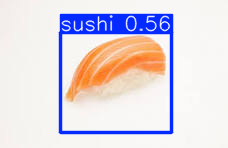

Testing: /content/test/test2.jpeg

image 1/1 /content/test/test2.jpeg: 448x640 2 sushis, 38.7ms
Speed: 1.9ms preprocess, 38.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


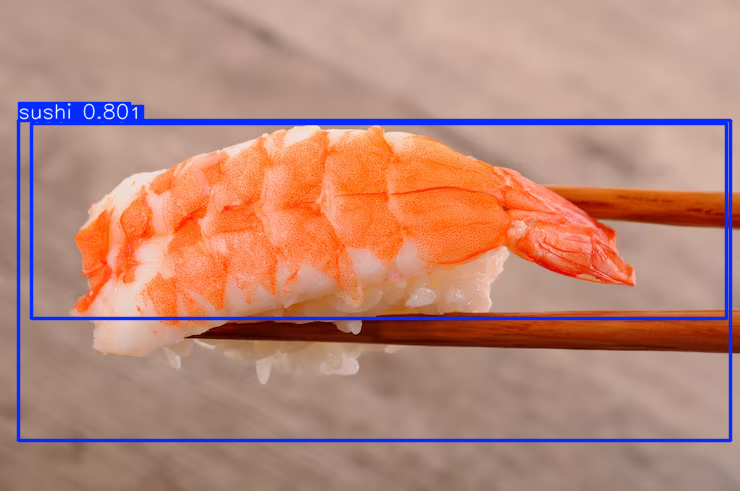

Testing: /content/test/test3.jpg

image 1/1 /content/test/test3.jpg: 448x640 1 sushi, 7.5ms
Speed: 3.5ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


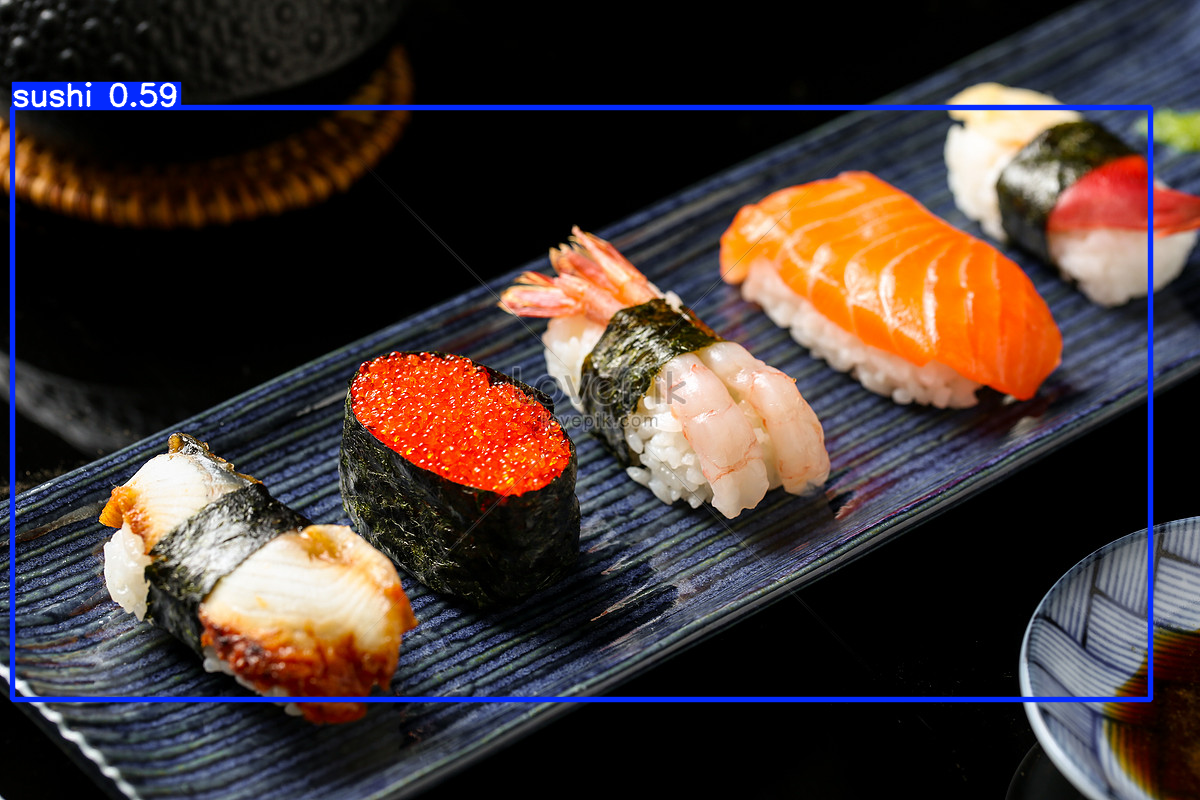

Testing: /content/test/test4.jpg

image 1/1 /content/test/test4.jpg: 480x640 2 sushis, 58.1ms
Speed: 3.1ms preprocess, 58.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


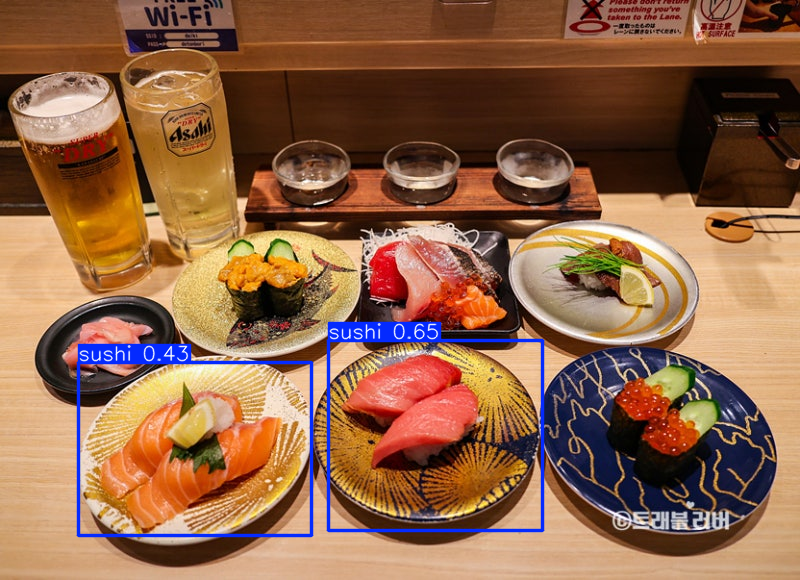

Testing: /content/test/test5.jpeg

image 1/1 /content/test/test5.jpeg: 480x640 1 sushi, 7.5ms
Speed: 3.5ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


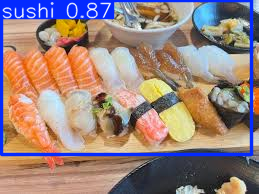

In [15]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2

# 학습한 모델 불러오기
model = YOLO("/content/runs/detect/train2/weights/best.pt")

# 테스트 이미지 리스트
test_images = [
    "/content/test/test1.jpeg",
    "/content/test/test2.jpeg",
    "/content/test/test3.jpg",
    "/content/test/test4.jpg",
    "/content/test/test5.jpeg"
]

# 각각 추론해서 결과 출력
for img_path in test_images:
    print("Testing:", img_path)
    results = model(img_path)

    # 결과 이미지 시각화
    for r in results:
        img = r.plot()   # 바운딩박스
        cv2_imshow(img)